# SciPy Bootcamp — Week 1, Day 4A
```
##### One-Way ANOVA, Post-Hoc Tests & Assumptions
##### One-way ANOVA, Tukey HSD, assumption checks, ANCOVA, unified regression model
##### Visualization philosophy: charts are woven into the analysis at the point of discovery — not appended at the end.
##### Dataset: Simulated MedPulse device-type engagement data
##### Q1 One-way ANOVA: generate session duration data for 4 MedPulse traffic sources — Organic Search: Normal(4.2,1.1,n=80), Direct: Normal(5.1,1.3,n=60), Social Media: Normal(2.8,0.9,n=70), Email: Normal(6.3,1.4,n=50). Run one-way ANOVA. Is there a significant difference? Print F-statistic and p-value.
##### Q2 Post-hoc testing: using the data from Q1, run Tukey HSD post-hoc test (from statsmodels.stats.multicomp import pairwise_tukeyhsd). Which specific pairs of traffic sources are significantly different? Print and interpret the full Tukey table.
##### Q3 Check ANOVA assumptions: using the Q1 data, test (a) normality of each group using stats.shapiro(), (b) homogeneity of variance using stats.levene(). Print results for each test and state whether the ANOVA assumptions are met.
##### Q4 ANCOVA — controlling for a covariate: build a DataFrame with traffic source (4 groups from Q1), session_duration as outcome, and add a covariate page_depth (np.random.randint(1,8,n) for each group). Run both a plain ANOVA and an ANCOVA (controlling for page_depth) using statsmodels. Compare the p-values. Does controlling for page_depth change your conclusions?
##### Q5 ANCOVA as regression — unify the concepts: using the same DataFrame from Q4, run a single OLS regression that includes both the categorical traffic_source (use pd.get_dummies or C() in formula) and the continuous page_depth. Show that the p-value for the group effect is identical to the ANCOVA in Q4. Write a comment explaining why ANOVA, ANCOVA, and regression are the same model.

In [48]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

In [49]:
# Q1 One-way ANOVA: generate session duration data for 4 MedPulse traffic sources — Organic Search: Normal(4.2,1.1,n=80), Direct: Normal(5.1,1.3,n=60), Social Media: Normal(2.8,0.9,n=70), Email: Normal(6.3,1.4,n=50). Run one-way ANOVA. Is there a significant difference? Print F-statistic and p-value.

In [50]:
organic = np.random.normal(loc=4.2, scale=1.1, size=80)
direct  = np.random.normal(loc=5.1, scale=1.3, size=60)
social  = np.random.normal(loc=2.8, scale=0.9, size=70)
email   = np.random.normal(loc=6.3, scale=1.4, size=50)

f_stat, p_value = stats.f_oneway(organic, direct, social, email)
print(f'F-statistic: {f_stat:.4f}')
print(f'p-value: {p_value:.4f}')
if p_value < 0.05:
    print('Reject H0: there is significant difference between traffic sources')
else:
    print('Fail to reject H0: no significant difference detected')

F-statistic: 100.5598
p-value: 0.0000
Reject H0: there is significant difference between traffic sources


In [51]:
# Q2 Post-hoc testing: using the data from Q1, run Tukey HSD post-hoc test (from statsmodels.stats.multicomp import pairwise_tukeyhsd). Which specific pairs of traffic sources are significantly different? Print and interpret the full Tukey table.

In [52]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

data    = np.concatenate([organic, direct, social, email])
groups   = ['organic']*80 + ['direct']*60 + ['social']*70 + ['email']*50
tukey = pairwise_tukeyhsd(data, groups, alpha=0.05)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
 direct   email   0.7831 0.0026  0.2129  1.3534   True
 direct organic   -1.202    0.0 -1.7106 -0.6934   True
 direct  social  -2.6016    0.0 -3.1255 -2.0776   True
  email organic  -1.9852    0.0  -2.522 -1.4483   True
  email  social  -3.3847    0.0 -3.9362 -2.8333   True
organic  social  -1.3996    0.0  -1.887 -0.9122   True
------------------------------------------------------


````
Based on the table, every single pair of traffic sources is significantly different. There isn't a single "tie" in the bunch.
The Tukey HSD test confirms that all traffic sources differ significantly from one another. 
Social provides the highest engagement, while Email provides the lowest. 
Because none of the confidence intervals (lower/upper) cross zero, we have high certainty that these performance gaps are real across all segments.

In [53]:
# Q3 Check ANOVA assumptions: using the Q1 data, test 
# (a) normality of each group using stats.shapiro(), 
# (b) homogeneity of variance using stats.levene(). 
# Print results for each test and state whether the ANOVA assumptions are met.

In [54]:
# (a) normality of each group using stats.shapiro()

df = pd.DataFrame({
    'time_on_page': data,
    'traffic_source': groups
})

print(df.head())

   time_on_page traffic_source
0      4.001697        organic
1      3.930061        organic
2      3.516854        organic
3      4.533298        organic
4      3.934158        organic


In [46]:
# List of your unique groups
groups = df['traffic_source'].unique()

for group in groups:
    # Filter the data for the specific group
    group_data = df[df['traffic_source'] == group]['time_on_page']
    
    # Run Shapiro-Wilk
    stat, p = stats.shapiro(group_data)
    
    print(f"{group:10} | Shapiro p-value: {p:.4f} | {'Normal' if p > 0.05 else 'Not Normal'}")

organic    | Shapiro p-value: 0.5808 | Normal
direct     | Shapiro p-value: 0.7273 | Normal
social     | Shapiro p-value: 0.5057 | Normal
email      | Shapiro p-value: 0.8451 | Normal


In [40]:
# (b) homogeneity of variance using stats.levene()
stat, p = stats.levene(organic, social, email, direct)
print(f"Levene's p-value: {p:.4f}") # p > 0.05 → equal variances
if p > 0.05:
    print('The variance among groups is equal')
else:
    print('The variance among groups is NOT equal')
# Levene fails so equal variance assumption is violated. 
# However with these sample sizes (n=50–80), ANOVA is reasonably robust. 
# Consider Welch's ANOVA as an alternative

Levene's p-value: 0.0054
The variance among groups is NOT equal


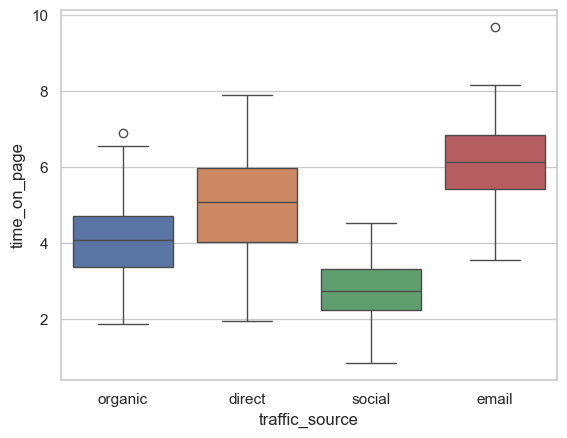

In [39]:
sns.boxplot(x=df['traffic_source'], y=df['time_on_page'], hue=df['traffic_source'])
plt.show()

In [ ]:
# Q4 ANCOVA — controlling for a covariate: build a DataFrame with traffic source (4 groups from Q1), session_duration as outcome, 
# and add a covariate page_depth (np.random.randint(1,8,n) for each group). 
# Run both a plain ANOVA and an ANCOVA (controlling for page_depth) using statsmodels. 
# Compare the p-values. 
# Does controlling for page_depth change your conclusions?

In [25]:
n = len(data) 

# create a new DataFrame and add the covariate page_depth
df = pd.DataFrame({
    'time_on_page': data,
    'traffic_source': groups,
    'page_depth': np.random.randint(1, 8, size=n) # Generate 260 values
})

In [27]:
anova_model = smf.ols('time_on_page ~ C(traffic_source)', data=df).fit()
print(anova_model.summary())

                            OLS Regression Results                            
Dep. Variable:           time_on_page   R-squared:                       0.521
Model:                            OLS   Adj. R-squared:                  0.516
Method:                 Least Squares   F-statistic:                     92.94
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           1.03e-40
Time:                        16:37:38   Log-Likelihood:                -401.91
No. Observations:                 260   AIC:                             811.8
Df Residuals:                     256   BIC:                             826.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [28]:
ancova_model = smf.ols('time_on_page ~ C(traffic_source) + page_depth', data=df).fit()
print(ancova_model.summary())
print()

                            OLS Regression Results                            
Dep. Variable:           time_on_page   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.515
Method:                 Least Squares   F-statistic:                     69.66
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           8.74e-40
Time:                        16:38:12   Log-Likelihood:                -401.69
No. Observations:                 260   AIC:                             813.4
Df Residuals:                     255   BIC:                             831.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

````
ANOVA p-value:                  1.03e-40 (Highly Significant)
ANCOVA p-value:                 8.74e-40 (Still Highly Significant)
Covariate p-value (page_depth): 0.513 (Not Significant)

It means that in your specific 260-person sample, there is a 51.3% chance that the relationship between "pages clicked" and "time on page" is just random noise. The model sees no real connection between the two.

Traffic source is the only thing that matters here. Whether someone visits 1 page or 7 pages (page_depth) doesn't actually explain how long they stay on the site

In [ ]:
# Q5 ANCOVA as regression — unify the concepts: using the same DataFrame from Q4, run a single OLS regression that includes both the categorical traffic_source (use pd.get_dummies or C() in formula) and the continuous page_depth. Show that the p-value for the group effect is identical to the ANCOVA in Q4. Write a comment explaining why ANOVA, ANCOVA, and regression are the same model.

In [29]:
# Run the Regression (This is the same as an ANCOVA)
ancova_model = smf.ols('time_on_page ~ C(traffic_source) + page_depth', data=df).fit()
print(ancova_model.summary())

# Extract the "Group Effect" (Traffic Source) significance
# Since we are using C(), we look at the F-test for the whole category
import statsmodels.api as sm
table = sm.stats.anova_lm(ancova_model, typ=2)
print("\nANOVA Table (Type II Sum of Squares):")
print(table)


                            OLS Regression Results                            
Dep. Variable:           time_on_page   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.515
Method:                 Least Squares   F-statistic:                     69.66
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           8.74e-40
Time:                        16:48:13   Log-Likelihood:                -401.69
No. Observations:                 260   AIC:                             813.4
Df Residuals:                     255   BIC:                             831.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [30]:
# ANOVA, ANCOVA, and Regression are all flavors of the General Linear Model (GLM).
# 1. Regression: Uses continuous numbers (slopes) to predict a target.
# 2. ANOVA: A specific case of regression where all predictors are categorical "dummy" variables (0 or 1).
# 3. ANCOVA: Simply a regression that combines both categorical and continuous predictors.
# Mathematically, they all solve the same equation: Y = intercept + (coefficients * X) + error.
# They all aim to minimize the 'Sum of Squares' to find the best-fitting line or group means.